**Section 1 — Title**
**CredResolve Collection Intelligence**

Data Analyst Assignment

Objective: Analyze the collections lifecycle from account targeting and customer engagement to promises-to-pay and payment outcomes, identify data-quality issues, and derive actionable insights for improving collection effectiveness and prioritization.

Tools: Python | SQL | Statistics | Data Visualization

1. Business Problem

CredResolve operates in technology-driven recovery management, where effective collection depends on identifying the right accounts, using appropriate collection channels, and converting collection efforts into successful recovery.

This project analyzes the provided collections dataset to understand:

- Where the portfolio's financial exposure is concentrated
- How collection activities are being performed
- Which collection outcomes are being observed
- How promises-to-pay translate into actual payments
- Where data-quality issues may affect business reporting
- Which areas may provide opportunities for better collection prioritization

The analysis follows the journey:

**Account → Targeting → Collection Activity → Engagement/Outcome → Promise to Pay → Payment**

 Project Objectives

1. Understand the structure and relationships across the provided datasets.
2. Assess and improve the quality of the raw data before analysis.
3. Build reliable analytical datasets for portfolio and collection analysis.
4. Use SQL to answer important business questions.
5. Perform exploratory and statistical analysis using Python.
6. Develop meaningful collection and recovery KPIs.
7. Analyze the relationship between collection activity, promises-to-pay, and payment outcomes.
8. Identify actionable patterns that can support collection prioritization.
9. Present the findings through clear visualizations and business recommendations.

## Executive Summary

This analysis evaluates the CredResolve collections lifecycle using the provided multi-table collections dataset.

The analysis covers portfolio exposure, collection activity, payment behaviour, promises-to-pay, delinquency, and data quality. A validated account-level analytical dataset was created by integrating relevant collection and payment information.

The portfolio contains approximately ₹10.49 billion in outstanding exposure and ₹1.88 billion in recorded payments, resulting in an overall collection rate of approximately 17.92%.

The analysis also identifies accounts with unresolved promises-to-pay, high delinquency, significant outstanding exposure, and limited payment activity. These signals are combined into an explainable collection-prioritization framework to help focus collection efforts on accounts with stronger potential business impact.

The analysis demonstrates how data quality, SQL, Python-based analytics, visualization, and business reasoning can be combined to support collection decision-making.

Environment Setup

The analysis uses Python for data loading, quality assessment, preprocessing, analysis, and visualization.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Environment setup completed successfully.")

Environment setup completed successfully.


Load the Provided Dataset

The provided CredResolve dataset is supplied as a ZIP archive containing multiple relational CSV files. The archive is extracted before the individual tables are loaded for analysis.

In [118]:
from google.colab import files

uploaded = files.upload()

Saving collections_30k_dataset.zip to collections_30k_dataset (2).zip


In [119]:
import zipfile
import os

zip_path = "collections_30k_dataset.zip"
extract_path = "credresolve_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print(os.listdir(extract_path))

Dataset extracted successfully.
['call_dispositions.csv', 'sms_events.csv', 'payments.csv', 'accounts.csv', 'agent_sessions.csv', 'README.md', 'account_status_history.csv', 'field_visits.csv', 'call_attempts.csv', 'calls.csv', 'agents.csv', 'complaints.csv', 'borrowers.csv', 'campaigns.csv', 'vendor_telephony.csv', 'daily_targeting.csv', 'whatsapp_events.csv', 'data_dictionary.csv', 'promises_to_pay.csv']


Dataset Overview

The provided CredResolve dataset contains multiple relational tables representing borrowers, accounts, collection activities, communication channels, promises-to-pay, payments, campaigns, and customer-service events.

Before performing any cleaning or analysis, the structure and quality of each table are assessed. This helps us understand the relationships between datasets and identify potential data-quality issues that could affect business KPIs.

In [120]:

files = os.listdir(extract_path)

print(f"Number of files found: {len(files)}")
print("\nFiles:")

for file in files:
    print("-", file)

Number of files found: 19

Files:
- call_dispositions.csv
- sms_events.csv
- payments.csv
- accounts.csv
- agent_sessions.csv
- README.md
- account_status_history.csv
- field_visits.csv
- call_attempts.csv
- calls.csv
- agents.csv
- complaints.csv
- borrowers.csv
- campaigns.csv
- vendor_telephony.csv
- daily_targeting.csv
- whatsapp_events.csv
- data_dictionary.csv
- promises_to_pay.csv


In [121]:
# Create a quick inventory of all CSV files

csv_files = [file for file in files if file.endswith(".csv")]

inventory = []

for file in csv_files:
    file_path = os.path.join(extract_path, file)
    df = pd.read_csv(file_path)

    inventory.append({
        "Dataset": file.replace(".csv", ""),
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    })

inventory_df = pd.DataFrame(inventory)

inventory_df

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,call_dispositions,35000,8,0,0
1,sms_events,45000,8,0,0
2,payments,25500,9,382,486
3,accounts,30000,11,455,0
4,agent_sessions,15000,7,0,0
5,account_status_history,60000,8,0,0
6,field_visits,25000,10,250,0
7,call_attempts,120000,9,2400,0
8,calls,91350,11,1827,1271
9,agents,30000,8,0,0


Loading the Dataset Tables

The extracted CSV files are loaded into separate pandas DataFrames. Each table represents a different business entity or event within the collections ecosystem.

At this stage, the data is loaded in its raw form. No records are removed or modified.

In [122]:
datasets = {}

for file in csv_files:
    file_path = os.path.join(extract_path, file)
    table_name = file.replace(".csv", "")
    datasets[table_name] = pd.read_csv(file_path)

print("Tables loaded successfully:")
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Tables loaded successfully:
call_dispositions: 35,000 rows × 8 columns
sms_events: 45,000 rows × 8 columns
payments: 25,500 rows × 9 columns
accounts: 30,000 rows × 11 columns
agent_sessions: 15,000 rows × 7 columns
account_status_history: 60,000 rows × 8 columns
field_visits: 25,000 rows × 10 columns
call_attempts: 120,000 rows × 9 columns
calls: 91,350 rows × 11 columns
agents: 30,000 rows × 8 columns
complaints: 8,000 rows × 9 columns
borrowers: 30,600 rows × 8 columns
campaigns: 120 rows × 7 columns
vendor_telephony: 15 rows × 6 columns
daily_targeting: 45,000 rows × 7 columns
whatsapp_events: 60,600 rows × 8 columns
data_dictionary: 143 rows × 3 columns
promises_to_pay: 18,000 rows × 9 columns


Table Structure

We inspect the columns and data types of each table to understand what information is available and identify potential keys, dates, categorical fields, and numerical measures.

In [123]:

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(f"TABLE: {name}")
    print("=" * 70)
    print(df.dtypes)


TABLE: call_dispositions
disposition_id         object
account_id             object
borrower_id            object
event_at               object
call_id                object
agent_id               object
disposition_code       object
disposition_version    object
dtype: object

TABLE: sms_events
sms_event_id     object
account_id       object
borrower_id      object
event_at         object
message_id       object
event_type       object
template_code    object
provider_id      object
dtype: object

TABLE: payments
payment_id            object
account_id            object
borrower_id           object
event_at              object
payment_reference     object
amount               float64
payment_status        object
payment_method        object
provider_id           object
dtype: object

TABLE: accounts
account_id             object
borrower_id            object
loan_type              object
principal_amount      float64
outstanding_amount    float64
dpd                     int64
risk_s

Data Dictionary

The provided data dictionary is used as the primary reference for understanding field definitions, business meanings, and expected data values before performing transformations or calculations.

In [124]:
data_dictionary = pd.read_csv(
    os.path.join(extract_path, "data_dictionary.csv")
)

print("Shape:", data_dictionary.shape)

display(data_dictionary.head(20))

Shape: (143, 3)


,dataset,column,dtype
0,borrowers,borrower_id,object
1,borrowers,name,object
2,borrowers,phone,object
3,borrowers,email,object
4,borrowers,city,object
5,borrowers,created_at,datetime64[ns]
6,borrowers,updated_at,datetime64[ns]
7,borrowers,state,object
8,accounts,account_id,object
9,accounts,borrower_id,object


Dataset Documentation

The README supplied with the dataset is reviewed to identify known data-quality challenges, business rules, and considerations that may affect analysis.

In [125]:
readme_path = os.path.join(extract_path, "README.md")

with open(readme_path, "r", encoding="utf-8") as f:
    readme_text = f.read()

print(readme_text)

# Synthetic Collections Analytics Dataset

Generated for a data-analyst challenge. Seed = 42.

The package contains 17 relational datasets and intentionally includes:
- duplicates
- missing values
- conflicting timestamps
- UTC / Asia/Kolkata / Asia/Dubai timestamps
- inconsistent identifiers
- late-arriving events
- schema versions
- legacy disposition codes
- duplicate payment references/events
- overwritten-style status history
- multiple agent identifiers
- inconsistent campaign definitions

Important: event-table row counts are intentionally different. Some tables exceed their nominal size because duplicate rows were injected.



Initial Structural Observations

The dataset follows a relational event-based structure centered around `account_id` and `borrower_id`. The `accounts` table represents the core portfolio, while the remaining tables capture different collection activities and outcomes.

Several event tables contain substantially more records than the 30,000 accounts because an account can generate multiple collection events over time. The dataset also contains multiple identifiers such as `account_id`, `borrower_id`, `call_id`, `agent_id`, `campaign_id`, and `payment_id`, which will require relationship and uniqueness validation before aggregation.

The README also indicates that duplicate events, inconsistent identifiers, multiple time zones, schema versions, and late-arriving events are intentionally present. Therefore, data-quality validation will be performed before calculating business KPIs.

In [126]:
# Display the provided data dictionary

pd.set_option("display.max_colwidth", 200)

display(data_dictionary)

,dataset,column,dtype
0,borrowers,borrower_id,object
1,borrowers,name,object
2,borrowers,phone,object
3,borrowers,email,object
4,borrowers,city,object
...,...,...,...
138,account_status_history,event_at,datetime64[ns]
139,account_status_history,status,object
140,account_status_history,changed_by,object
141,account_status_history,source,object


Data Quality Assessment

Before calculating business KPIs, the raw datasets are assessed for common data-quality issues including missing values, exact duplicate records, duplicate identifiers, and inconsistent relationships between tables.

The objective is not to remove records blindly, but to identify issues and define appropriate handling rules based on the business meaning of each table.

In [127]:
# Create a detailed data-quality summary

quality_summary = []

for name, df in datasets.items():
    quality_summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Cells": int(df.isna().sum().sum()),
        "Missing %": round(df.isna().mean().mean() * 100, 2),
        "Exact Duplicate Rows": int(df.duplicated().sum())
    })

quality_df = pd.DataFrame(quality_summary)

quality_df.sort_values(
    by=["Missing Cells", "Exact Duplicate Rows"],
    ascending=False
)

,Dataset,Rows,Columns,Missing Cells,Missing %,Exact Duplicate Rows
7,call_attempts,120000,9,2400,0.22,0
8,calls,91350,11,1827,0.18,1271
11,borrowers,30600,8,1509,0.62,600
3,accounts,30000,11,455,0.14,0
2,payments,25500,9,382,0.17,486
6,field_visits,25000,10,250,0.10,0
15,whatsapp_events,60600,8,0,0.00,600
0,call_dispositions,35000,8,0,0.00,0
1,sms_events,45000,8,0,0.00,0
4,agent_sessions,15000,7,0,0.00,0


Missing Value Assessment

Missing values are examined at column level to distinguish between fields that are essential for analysis and fields where missingness may be expected or acceptable.

In [128]:
# Show columns containing missing values

missing_details = []

for name, df in datasets.items():
    for column in df.columns:
        missing_count = int(df[column].isna().sum())

        if missing_count > 0:
            missing_details.append({
                "Dataset": name,
                "Column": column,
                "Missing Count": missing_count,
                "Missing %": round(
                    df[column].isna().mean() * 100, 2
                )
            })

missing_df = pd.DataFrame(missing_details)

missing_df.sort_values(
    by="Missing %",
    ascending=False
)

,Dataset,Column,Missing Count,Missing %
6,borrowers,email,895,2.92
5,borrowers,phone,614,2.01
4,calls,agent_id,1827,2.00
3,call_attempts,vendor_id,2400,2.00
1,accounts,borrower_id,455,1.52
0,payments,payment_reference,382,1.50
2,field_visits,scheduled_at,250,1.00


 Duplicate Record Assessment

The README indicates that duplicate events were intentionally introduced into the dataset. Exact duplicate rows are therefore measured before any transformation.

Duplicate records will not be removed automatically because event-level datasets may legitimately contain repeated business events.

In [129]:
# Show tables containing exact duplicate rows

duplicate_summary = quality_df[
    quality_df["Exact Duplicate Rows"] > 0
].sort_values(
    "Exact Duplicate Rows",
    ascending=False
)

duplicate_summary

,Dataset,Rows,Columns,Missing Cells,Missing %,Exact Duplicate Rows
8,calls,91350,11,1827,0.18,1271
11,borrowers,30600,8,1509,0.62,600
15,whatsapp_events,60600,8,0,0.00,600
2,payments,25500,9,382,0.17,486


In [130]:
display(
    missing_df.sort_values(
        by="Missing %",
        ascending=False
    )
)

,Dataset,Column,Missing Count,Missing %
6,borrowers,email,895,2.92
5,borrowers,phone,614,2.01
4,calls,agent_id,1827,2.00
3,call_attempts,vendor_id,2400,2.00
1,accounts,borrower_id,455,1.52
0,payments,payment_reference,382,1.50
2,field_visits,scheduled_at,250,1.00


In [131]:
display(duplicate_summary)

,Dataset,Rows,Columns,Missing Cells,Missing %,Exact Duplicate Rows
8,calls,91350,11,1827,0.18,1271
11,borrowers,30600,8,1509,0.62,600
15,whatsapp_events,60600,8,0,0.00,600
2,payments,25500,9,382,0.17,486


In [132]:
# Check uniqueness of important identifiers

key_columns = {
    "borrowers": "borrower_id",
    "accounts": "account_id",
    "agents": "agent_id",
    "campaigns": "campaign_id",
    "calls": "call_id",
    "call_attempts": "attempt_id",
    "call_dispositions": "disposition_id",
    "payments": "payment_id",
    "promises_to_pay": "ptp_id",
    "field_visits": "visit_id",
    "daily_targeting": "target_id",
    "complaints": "complaint_id",
    "sms_events": "sms_event_id",
    "whatsapp_events": "whatsapp_event_id",
    "agent_sessions": "session_id"
}

key_check = []

for table, key in key_columns.items():
    df = datasets[table]

    key_check.append({
        "Dataset": table,
        "Key": key,
        "Rows": len(df),
        "Unique Keys": df[key].nunique(dropna=True),
        "Duplicate Key Rows": int(df[key].duplicated().sum()),
        "Missing Keys": int(df[key].isna().sum())
    })

key_check_df = pd.DataFrame(key_check)

display(key_check_df)

,Dataset,Key,Rows,Unique Keys,Duplicate Key Rows,Missing Keys
0,borrowers,borrower_id,30600,11015,19585,0
1,accounts,account_id,30000,30000,0,0
2,agents,agent_id,30000,1000,29000,0
3,campaigns,campaign_id,120,120,0,0
4,calls,call_id,91350,90000,1350,0
5,call_attempts,attempt_id,120000,120000,0,0
6,call_dispositions,disposition_id,35000,35000,0,0
7,payments,payment_id,25500,25000,500,0
8,promises_to_pay,ptp_id,18000,18000,0,0
9,field_visits,visit_id,25000,25000,0,0


Identifier Uniqueness Assessment

Exact duplicate rows do not necessarily represent duplicate business events. Identifier-level validation is therefore performed to determine whether supposedly unique event or entity identifiers occur multiple times.

This distinction is particularly important for financial events such as payments and operational events such as calls.

In [133]:
display(key_check_df)

,Dataset,Key,Rows,Unique Keys,Duplicate Key Rows,Missing Keys
0,borrowers,borrower_id,30600,11015,19585,0
1,accounts,account_id,30000,30000,0,0
2,agents,agent_id,30000,1000,29000,0
3,campaigns,campaign_id,120,120,0,0
4,calls,call_id,91350,90000,1350,0
5,call_attempts,attempt_id,120000,120000,0,0
6,call_dispositions,disposition_id,35000,35000,0,0
7,payments,payment_id,25500,25000,500,0
8,promises_to_pay,ptp_id,18000,18000,0,0
9,field_visits,visit_id,25000,25000,0,0


In [134]:
# Investigate duplicate payment references

payment_reference_check = (
    datasets['payments'].groupby("payment_reference")
    .size()
    .reset_index(name="Record_Count")
    .query("Record_Count > 1")
    .sort_values("Record_Count", ascending=False)
)

display(payment_reference_check.head(20))

,payment_reference,Record_Count
13081,TXN0000044312,5
1993,TXN0000006936,5
14862,TXN0000050468,5
15513,TXN0000052559,5
585,TXN0000002005,5
6280,TXN0000021482,5
19524,TXN0000065723,5
16926,TXN0000057390,4
3869,TXN0000013291,4
8063,TXN0000027440,4


In [135]:
# Investigate duplicate payment IDs

payment_id_check = (
    datasets['payments'].groupby("payment_id")
    .size()
    .reset_index(name="Record_Count")
    .query("Record_Count > 1")
    .sort_values("Record_Count", ascending=False)
)

display(payment_id_check.head(20))

,payment_id,Record_Count
24851,PAYMENT0024852,2
55,PAYMENT0000056,2
75,PAYMENT0000076,2
107,PAYMENT0000108,2
24309,PAYMENT0024310,2
24234,PAYMENT0024235,2
24176,PAYMENT0024177,2
24143,PAYMENT0024144,2
24142,PAYMENT0024143,2
24116,PAYMENT0024117,2


Payment Duplicate Investigation

Payment records require special handling because duplicate events can directly affect recovery and collection KPIs.

Rather than removing duplicate payment records based only on an identifier, the duplicated records are compared across account, amount, status, timestamp, and payment reference fields to determine whether they represent repeated copies of the same event or distinct transactions.

In [136]:
# Inspect records where payment_id appears more than once

duplicate_payment_ids = (
    datasets['payments']["payment_id"]
    .value_counts()
)

duplicate_payment_ids = duplicate_payment_ids[
    duplicate_payment_ids > 1
].index

duplicate_payment_rows = datasets['payments'][
    datasets['payments']["payment_id"].isin(duplicate_payment_ids)
].sort_values("payment_id")

display(duplicate_payment_rows.head(30))

,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id
55,PAYMENT0000056,ACC0019495,BRW0009716,2026-02-24 09:33:29,TXN0000008612,77982.73,PENDING,NETBANKING,VND0000007
25035,PAYMENT0000056,ACC0019495,BRW0009716,2026-02-24 09:33:29,TXN0000008612,77982.73,PENDING,NETBANKING,VND0000007
75,PAYMENT0000076,ACC0027928,BRW0010869,2026-02-05 17:14:30,TXN0000006417,43712.91,PENDING,UPI,VND0000014
25408,PAYMENT0000076,ACC0027928,BRW0010869,2026-02-05 17:14:30,TXN0000006417,43712.91,PENDING,UPI,VND0000014
107,PAYMENT0000108,ACC0017047,BRW0009175,2026-06-09 08:17:45,TXN0000041404,102830.42,SUCCESS,NACH,VND0000003
25481,PAYMENT0000108,ACC0017047,BRW0009175,2026-06-09 08:17:45,TXN0000041404,102830.42,SUCCESS,NACH,VND0000003
148,PAYMENT0000149,ACC0018444,BRW0005741,2026-07-25 03:04:14,TXN0000066565,96766.12,SUCCESS,CASH,VND0000013
25099,PAYMENT0000149,ACC0018444,BRW0005741,2026-07-25 03:04:14,TXN0000066565,96766.12,SUCCESS,CASH,VND0000013
198,PAYMENT0000199,ACC0000056,BRW0001872,2026-05-12 22:49:22,TXN0000069967,81814.00,SUCCESS,NETBANKING,VND0000012
25330,PAYMENT0000199,ACC0000056,BRW0001872,2026-05-12 22:49:22,TXN0000069967,81814.00,SUCCESS,NETBANKING,VND0000012


In [137]:
# Check whether duplicated payment_id records are completely identical

payment_id_duplicate_check = (
    duplicate_payment_rows
    .groupby("payment_id")
    .agg(
        Records=("payment_id", "size"),
        Unique_References=("payment_reference", "nunique"),
        Unique_Accounts=("account_id", "nunique"),
        Unique_Amounts=("amount", "nunique"),
        Unique_Statuses=("payment_status", "nunique"),
        Unique_Timestamps=("event_at", "nunique")
    )
    .reset_index()
)

display(payment_id_duplicate_check.head(30))

,payment_id,Records,Unique_References,Unique_Accounts,Unique_Amounts,Unique_Statuses,Unique_Timestamps
0,PAYMENT0000056,2,1,1,1,1,1
1,PAYMENT0000076,2,1,1,1,1,1
2,PAYMENT0000108,2,1,1,1,1,1
3,PAYMENT0000149,2,1,1,1,1,1
4,PAYMENT0000199,2,1,1,1,1,1
5,PAYMENT0000255,2,1,1,1,1,1
6,PAYMENT0000263,2,1,1,1,1,1
7,PAYMENT0000311,2,1,1,1,1,1
8,PAYMENT0000552,2,1,1,1,1,1
9,PAYMENT0000553,2,1,1,1,1,1


In [138]:
display(key_check_df)

,Dataset,Key,Rows,Unique Keys,Duplicate Key Rows,Missing Keys
0,borrowers,borrower_id,30600,11015,19585,0
1,accounts,account_id,30000,30000,0,0
2,agents,agent_id,30000,1000,29000,0
3,campaigns,campaign_id,120,120,0,0
4,calls,call_id,91350,90000,1350,0
5,call_attempts,attempt_id,120000,120000,0,0
6,call_dispositions,disposition_id,35000,35000,0,0
7,payments,payment_id,25500,25000,500,0
8,promises_to_pay,ptp_id,18000,18000,0,0
9,field_visits,visit_id,25000,25000,0,0


### 8.5 Entity-Level Duplicate Investigation

The borrower table contains more rows than unique borrower identifiers. Since a borrower may potentially be associated with multiple accounts or records, duplicate `borrower_id` values are not automatically treated as erroneous.

The records are therefore examined to determine whether they represent repeated copies, multiple account relationships, or conflicting borrower information.

In [139]:
# Inspect borrowers with repeated borrower_id values

borrower_counts = datasets['borrowers']["borrower_id"].value_counts()

duplicate_borrower_ids = borrower_counts[
    borrower_counts > 1
].index

duplicate_borrowers = datasets['borrowers'][
    datasets['borrowers']["borrower_id"].isin(duplicate_borrower_ids)
].sort_values("borrower_id")

display(duplicate_borrowers.head(30))

,borrower_id,name,phone,email,city,created_at,updated_at,state
5082,BRW0000001,Aarav Sharma,9.962893e+09,user8164@example.com,Kolkata,2025-11-04 23:36:22,2026-06-22 12:05:30,West Bengal
27686,BRW0000001,Aarav Sharma,9.237818e+09,user10670@example.com,Hyderabad,2025-12-03 00:18:45,2026-06-25 02:44:50,Telangana
20435,BRW0000001,Rohan Patel,9.712907e+09,user4799@example.com,Hyderabad,2026-07-17 04:33:13,2025-11-22 01:34:14,Telangana
20050,BRW0000004,Vikram Shah,9.072501e+09,user13710@example.com,Gurugram,2025-11-16 08:32:03,2025-10-31 11:10:43,Haryana
23818,BRW0000004,Ananya Rao,9.076787e+09,user15119@example.com,Delhi,2025-07-20 23:45:10,2025-12-20 18:43:35,Delhi
10963,BRW0000004,Neha Singh,9.714461e+09,user18767@example.com,Bengaluru,2025-07-03 17:14:49,2025-01-15 08:16:46,Karnataka
29546,BRW0000004,Pooja Nair,9.936985e+09,user11254@example.com,Mumbai,2026-02-10 12:40:50,2025-12-16 20:36:28,Maharashtra
30325,BRW0000005,Neha Singh,9.269813e+09,user4520@example.com,Mumbai,2026-02-07 14:08:27,2025-12-04 08:52:09,Maharashtra
18692,BRW0000005,Neha Singh,9.269813e+09,user4520@example.com,Mumbai,2026-02-07 14:08:27,2025-12-04 08:52:09,Maharashtra
8282,BRW0000005,Sneha Das,9.359023e+09,user5979@example.com,Pune,2026-03-18 14:01:59,2025-07-07 09:59:12,Maharashtra


In [140]:
# Check how much borrower information changes across repeated IDs

borrower_duplicate_check = (
    duplicate_borrowers
    .groupby("borrower_id")
    .agg(
        Records=("borrower_id", "size"),
        Unique_Names=("name", "nunique"),
        Unique_Phones=("phone", "nunique"),
        Unique_Emails=("email", "nunique"),
        Unique_Cities=("city", "nunique"),
        Unique_States=("state", "nunique")
    )
    .reset_index()
)

display(borrower_duplicate_check.head(30))

,borrower_id,Records,Unique_Names,Unique_Phones,Unique_Emails,Unique_Cities,Unique_States
0,BRW0000001,3,2,3,3,2,2
1,BRW0000004,4,4,4,4,4,4
2,BRW0000005,3,2,2,2,2,1
3,BRW0000006,3,3,3,3,2,2
4,BRW0000007,4,3,4,4,4,4
5,BRW0000009,3,3,3,2,3,3
6,BRW0000012,5,4,5,5,4,4
7,BRW0000013,4,3,4,4,3,3
8,BRW0000015,2,2,2,2,2,2
9,BRW0000016,4,4,4,4,2,2


Agent Identifier Assessment

The agents table contains repeated `agent_id` values. This suggests that the table may contain multiple records associated with the same agent rather than representing a simple one-row-per-agent master table.

The uniqueness of agent attributes is therefore examined before using the table for agent-level performance analysis.

In [141]:
# Check repeated agent IDs

agent_duplicate_check = (
    datasets['agents']
    .groupby("agent_id")
    .agg(
        Records=("agent_id", "size"),
        Unique_Employee_Codes=("employee_code", "nunique"),
        Unique_Names=("agent_name", "nunique"),
        Unique_Vendors=("vendor_id", "nunique"),
        Unique_Teams=("team", "nunique"),
        Unique_Statuses=("status", "nunique")
    )
    .reset_index()
)

display(agent_duplicate_check.head(30))

,agent_id,Records,Unique_Employee_Codes,Unique_Names,Unique_Vendors,Unique_Teams,Unique_Statuses
0,AGT0000001,23,23,10,10,5,3
1,AGT0000002,23,23,10,12,5,3
2,AGT0000003,28,28,10,12,5,3
3,AGT0000004,28,28,10,12,5,3
4,AGT0000005,29,29,10,15,5,3
5,AGT0000006,37,37,10,15,5,3
6,AGT0000007,30,29,10,15,5,3
7,AGT0000008,29,29,10,12,5,3
8,AGT0000009,25,24,10,12,5,3
9,AGT0000010,26,26,10,15,5,3


Referential Integrity

The account table is treated as the central portfolio table. Its relationships with borrower and operational event tables are validated before creating analytical joins.

This prevents unmatched records from silently distorting portfolio, collection, and recovery metrics.

In [142]:
# Validate account-to-borrower relationship

account_borrower_check = datasets['accounts'][
    ~datasets['accounts']["borrower_id"].isin(datasets['borrowers']["borrower_id"])
]

print("Accounts with borrower IDs not found in borrowers:",
      len(account_borrower_check))

Accounts with borrower IDs not found in borrowers: 2913


In [143]:
# Validate calls-to-accounts relationship

calls_account_check = datasets['calls'][
    ~datasets['calls']["account_id"].isin(datasets['accounts']["account_id"])
]

print("Calls with account IDs not found in accounts:",
      len(calls_account_check))

Calls with account IDs not found in accounts: 0


In [144]:
# Validate payments-to-accounts relationship

payments_account_check = datasets['payments'][
    ~datasets['payments']["account_id"].isin(datasets['accounts']["account_id"])
]

print("Payments with account IDs not found in accounts:",
      len(payments_account_check))

Payments with account IDs not found in accounts: 0


In [145]:
display(borrower_duplicate_check.head(30))

,borrower_id,Records,Unique_Names,Unique_Phones,Unique_Emails,Unique_Cities,Unique_States
0,BRW0000001,3,2,3,3,2,2
1,BRW0000004,4,4,4,4,4,4
2,BRW0000005,3,2,2,2,2,1
3,BRW0000006,3,3,3,3,2,2
4,BRW0000007,4,3,4,4,4,4
5,BRW0000009,3,3,3,2,3,3
6,BRW0000012,5,4,5,5,4,4
7,BRW0000013,4,3,4,4,3,3
8,BRW0000015,2,2,2,2,2,2
9,BRW0000016,4,4,4,4,2,2


In [146]:
display(agent_duplicate_check.head(30))

,agent_id,Records,Unique_Employee_Codes,Unique_Names,Unique_Vendors,Unique_Teams,Unique_Statuses
0,AGT0000001,23,23,10,10,5,3
1,AGT0000002,23,23,10,12,5,3
2,AGT0000003,28,28,10,12,5,3
3,AGT0000004,28,28,10,12,5,3
4,AGT0000005,29,29,10,15,5,3
5,AGT0000006,37,37,10,15,5,3
6,AGT0000007,30,29,10,15,5,3
7,AGT0000008,29,29,10,12,5,3
8,AGT0000009,25,24,10,12,5,3
9,AGT0000010,26,26,10,15,5,3


Data Cleaning and Analytical Preparation

The raw datasets are preserved unchanged. Based on the quality assessment, analytical copies are created for downstream analysis.

Exact duplicate rows are removed from event-level datasets where they represent repeated copies of the same record. Core account records are retained, while financial and relationship data are handled carefully to avoid removing legitimate business events.

In [147]:
# Create analytical copies and remove exact duplicate rows

cleaned = {}

for name, df in datasets.items():
    cleaned[name] = df.drop_duplicates().copy()

print("Exact duplicate rows removed:")
for name in datasets:
    removed = len(datasets[name]) - len(cleaned[name])
    if removed > 0:
        print(f"{name}: {removed:,}")

Exact duplicate rows removed:
payments: 486
calls: 1,271
borrowers: 600
whatsapp_events: 600


Date Standardization

Date and timestamp fields are converted into a consistent datetime format to support reliable time-based analysis, trend analysis, and event sequencing.

In [148]:
# Convert columns containing date/time information

for name, df in cleaned.items():
    for column in df.columns:
        if any(word in column.lower() for word in ["date", "time", "at"]):
            try:
                df[column] = pd.to_datetime(df[column], errors="coerce")
            except:
                pass

print("Date/time standardization completed.")

/tmp/ipykernel_5152/842397934.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")
/tmp/ipykernel_5152/842397934.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")
/tmp/ipykernel_5152/842397934.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")
/tmp/ipykernel_5152/842397934.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing

Date/time standardization completed.


/tmp/ipykernel_5152/842397934.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")
/tmp/ipykernel_5152/842397934.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")
/tmp/ipykernel_5152/842397934.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")


 Analytical Base Table

The `accounts` table is used as the primary portfolio-level analytical base because each account represents a collection exposure. Additional collection activity and payment information are aggregated at account level before being joined to the portfolio.

This approach prevents one-to-many event relationships from artificially inflating account-level KPIs.

In [149]:
accounts_clean = cleaned["accounts"].copy()

print("Analytical account base:", accounts_clean.shape)
display(accounts_clean.head())

Analytical account base: (30000, 11)


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,NaT,2025-11-11 04:37:00,NaT,v1
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,NaT,2025-11-13 15:59:44,NaT,v3
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,NaT,2025-09-12 04:59:20,NaT,v2
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,NaT,2025-05-25 19:29:38,NaT,v2
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,NaT,2025-09-07 14:59:13,NaT,v2


In [150]:
payments_clean = cleaned["payments"].copy()

payment_summary = (
    payments_clean
    .groupby("account_id")
    .agg(
        total_payment=("amount", "sum"),
        payment_count=("payment_id", "nunique")
    )
    .reset_index()
)

payment_summary.head()

,account_id,total_payment,payment_count
0,ACC0000001,114222.84,1
1,ACC0000003,118181.69,2
2,ACC0000004,120763.00,1
3,ACC0000008,129255.53,1
4,ACC0000010,113781.45,1


In [151]:
calls_clean = cleaned["calls"].copy()

# Ensure 'duration_sec' is numeric before summing
calls_clean['duration_sec'] = pd.to_numeric(calls_clean['duration_sec'], errors='coerce')

call_summary = (
    calls_clean
    .groupby("account_id")
    .agg(
        call_count=("call_id", "nunique"),
        total_call_duration=("duration_sec", "sum")
    )
    .reset_index()
)

call_summary.head()

,account_id,call_count,total_call_duration
0,ACC0000001,1,44
1,ACC0000002,5,1238
2,ACC0000003,3,1937
3,ACC0000006,8,4463
4,ACC0000007,3,1084


In [152]:
ptp_clean = cleaned["promises_to_pay"].copy()

ptp_summary = (
    ptp_clean
    .groupby("account_id")
    .agg(
        ptp_count=("ptp_id", "nunique"),
        promised_amount=("promised_amount", "sum")
    )
    .reset_index()
)

ptp_summary.head()

,account_id,ptp_count,promised_amount
0,ACC0000001,1,44751.18
1,ACC0000008,1,76518.21
2,ACC0000012,1,10075.92
3,ACC0000015,2,91736.54
4,ACC0000016,1,22534.19


In [153]:
analysis_df = (
    accounts_clean
    .merge(payment_summary, on="account_id", how="left")
    .merge(call_summary, on="account_id", how="left")
    .merge(ptp_summary, on="account_id", how="left")
)

# Fill metrics for accounts with no recorded activity
metric_columns = [
    "total_payment",
    "payment_count",
    "call_count",
    "total_call_duration",
    "ptp_count",
    "promised_amount"
]

analysis_df[metric_columns] = analysis_df[metric_columns].fillna(0)

print("Final analytical dataset:", analysis_df.shape)

display(analysis_df.head())

Final analytical dataset: (30000, 17)


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version,total_payment,payment_count,call_count,total_call_duration,ptp_count,promised_amount
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,NaT,2025-11-11 04:37:00,NaT,v1,114222.84,1.0,1.0,44.0,1.0,44751.18
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,NaT,2025-11-13 15:59:44,NaT,v3,0.00,0.0,5.0,1238.0,0.0,0.00
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,NaT,2025-09-12 04:59:20,NaT,v2,118181.69,2.0,3.0,1937.0,0.0,0.00
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,NaT,2025-05-25 19:29:38,NaT,v2,120763.00,1.0,0.0,0.0,0.0,0.00
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,NaT,2025-09-07 14:59:13,NaT,v2,0.00,0.0,0.0,0.0,0.0,0.00


Collection Performance KPIs

The analytical dataset is used to calculate portfolio exposure, payment performance, collection activity, and promise-to-pay indicators at account level.

In [154]:
total_outstanding = analysis_df["outstanding_amount"].sum()
total_collected = analysis_df["total_payment"].sum()

collection_rate = (
    total_collected / total_outstanding * 100
    if total_outstanding > 0 else 0
)

ptp_accounts = (analysis_df["ptp_count"] > 0).sum()
paid_accounts = (analysis_df["payment_count"] > 0).sum()

print(f"Total Outstanding Exposure: ₹{total_outstanding:,.2f}")
print(f"Total Payments Collected: ₹{total_collected:,.2f}")
print(f"Collection Rate: {collection_rate:.2f}%")
print(f"Accounts with PTP: {ptp_accounts:,}")
print(f"Accounts with Payments: {paid_accounts:,}")

Total Outstanding Exposure: ₹10,489,035,343.00
Total Payments Collected: ₹1,879,959,597.35
Collection Rate: 17.92%
Accounts with PTP: 13,532
Accounts with Payments: 16,934


## 12. Exploratory Data Analysis

### 12.1 Portfolio Exposure by Risk Segment

Understanding how outstanding exposure is distributed across risk segments helps identify where the largest financial exposure is concentrated.

In [155]:
risk_summary = (
    analysis_df
    .groupby("risk_segment")
    .agg(
        accounts=("account_id", "nunique"),
        outstanding=("outstanding_amount", "sum"),
        payments=("total_payment", "sum")
    )
    .reset_index()
)

risk_summary["collection_rate"] = (
    risk_summary["payments"] /
    risk_summary["outstanding"] * 100
)

display(risk_summary)

,risk_segment,accounts,outstanding,payments,collection_rate
0,HIGH,7552,2.646183e+09,4.713486e+08,17.812400
1,LOW,7513,2.633311e+09,4.771991e+08,18.121636
2,MEDIUM,7533,2.628179e+09,4.680344e+08,17.808314
3,NPA,7402,2.581362e+09,4.633775e+08,17.950889


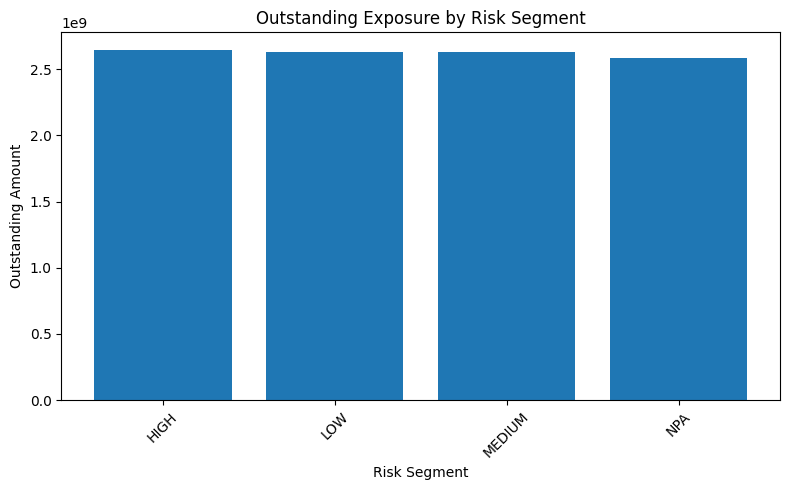

In [156]:
plt.figure(figsize=(8,5))

plt.bar(
    risk_summary["risk_segment"],
    risk_summary["outstanding"]
)

plt.title("Outstanding Exposure by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Outstanding Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

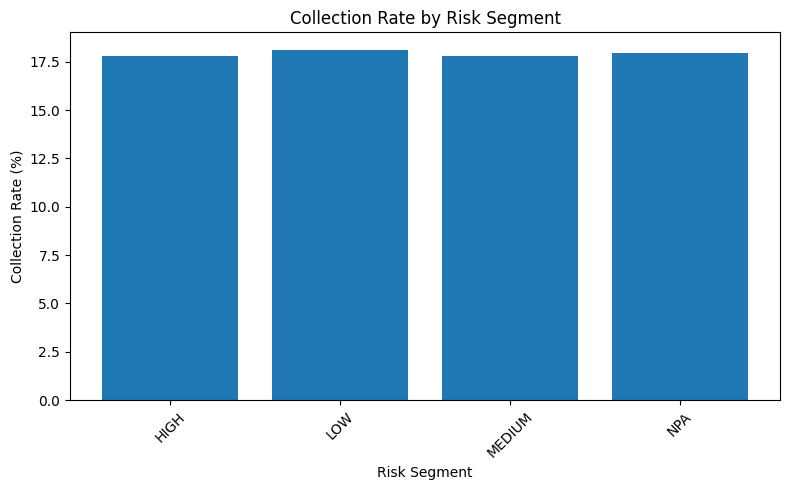

In [157]:
plt.figure(figsize=(8,5))

plt.bar(
    risk_summary["risk_segment"],
    risk_summary["collection_rate"]
)

plt.title("Collection Rate by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Collection Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 12.2 Outstanding Exposure vs Payments

Comparing outstanding exposure with actual payments helps quantify the recovery gap across risk segments.

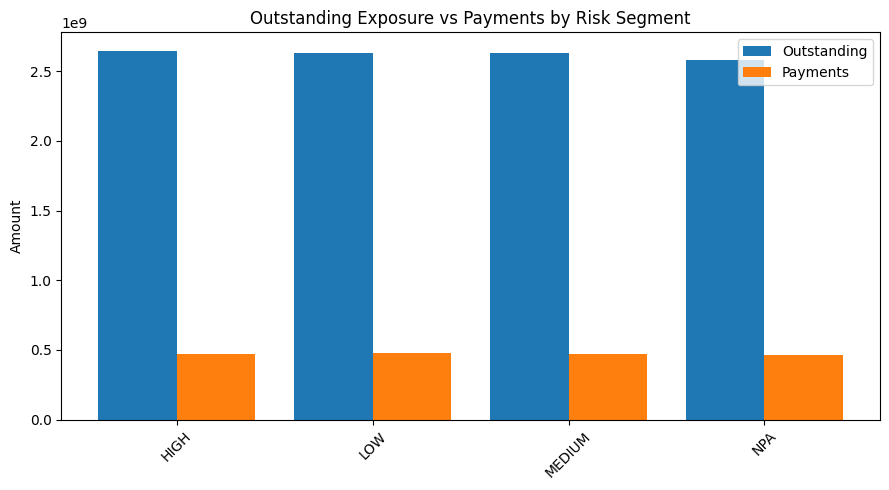

In [158]:
plt.figure(figsize=(9,5))

x = np.arange(len(risk_summary))

plt.bar(
    x - 0.2,
    risk_summary["outstanding"],
    width=0.4,
    label="Outstanding"
)

plt.bar(
    x + 0.2,
    risk_summary["payments"],
    width=0.4,
    label="Payments"
)

plt.xticks(x, risk_summary["risk_segment"], rotation=45)
plt.ylabel("Amount")
plt.title("Outstanding Exposure vs Payments by Risk Segment")
plt.legend()

plt.tight_layout()
plt.show()

### 12.3 Collection Activity and Payment Outcomes

Collection activity is compared with payment outcomes to understand whether higher account-level engagement is associated with payment activity.

In [159]:
activity_summary = (
    analysis_df
    .groupby("call_count")
    .agg(
        accounts=("account_id", "nunique"),
        total_payment=("total_payment", "sum")
    )
    .reset_index()
)

display(activity_summary.head(15))

,call_count,accounts,total_payment
0,0.0,1592,9.878664e+07
1,1.0,4416,2.805047e+08
2,2.0,6629,4.099913e+08
3,3.0,6785,4.277243e+08
4,4.0,5030,3.150977e+08
5,5.0,3009,1.880458e+08
6,6.0,1507,9.516837e+07
7,7.0,654,3.814249e+07
8,8.0,265,1.863338e+07
9,9.0,78,5.785590e+06


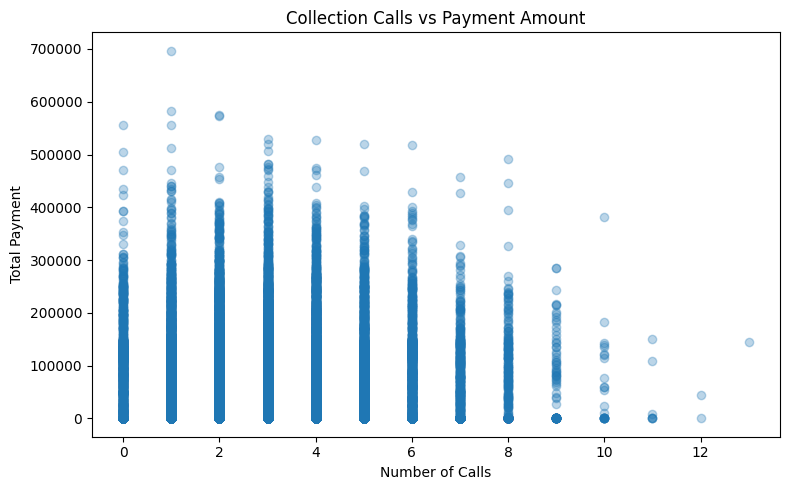

In [160]:
plt.figure(figsize=(8,5))

plt.scatter(
    analysis_df["call_count"],
    analysis_df["total_payment"],
    alpha=0.3
)

plt.title("Collection Calls vs Payment Amount")
plt.xlabel("Number of Calls")
plt.ylabel("Total Payment")

plt.tight_layout()
plt.show()

### 12.4 Delinquency and Financial Exposure

Days Past Due (DPD) is examined against outstanding exposure to understand how delinquency levels relate to the portfolio's financial risk.

In [161]:
dpd_summary = (
    analysis_df
    .groupby("dpd")
    .agg(
        accounts=("account_id", "nunique"),
        outstanding=("outstanding_amount", "sum"),
        payments=("total_payment", "sum")
    )
    .reset_index()
)

dpd_summary["collection_rate"] = (
    dpd_summary["payments"] /
    dpd_summary["outstanding"] * 100
)

display(dpd_summary.head(20))

,dpd,accounts,outstanding,payments,collection_rate
0,0,2685,9.482186e+08,1.674385e+08,17.658221
1,1,2713,9.413997e+08,1.691627e+08,17.969272
2,5,2727,9.727499e+08,1.731238e+08,17.797363
3,15,2736,9.762298e+08,1.676746e+08,17.175732
4,30,2704,9.437212e+08,1.638333e+08,17.360348
5,45,2744,9.460511e+08,1.779348e+08,18.808155
6,60,2770,9.684392e+08,1.809104e+08,18.680614
7,75,2741,9.449780e+08,1.694646e+08,17.933176
8,90,2727,9.508904e+08,1.730065e+08,18.194162
9,120,2759,9.759497e+08,1.744296e+08,17.872805


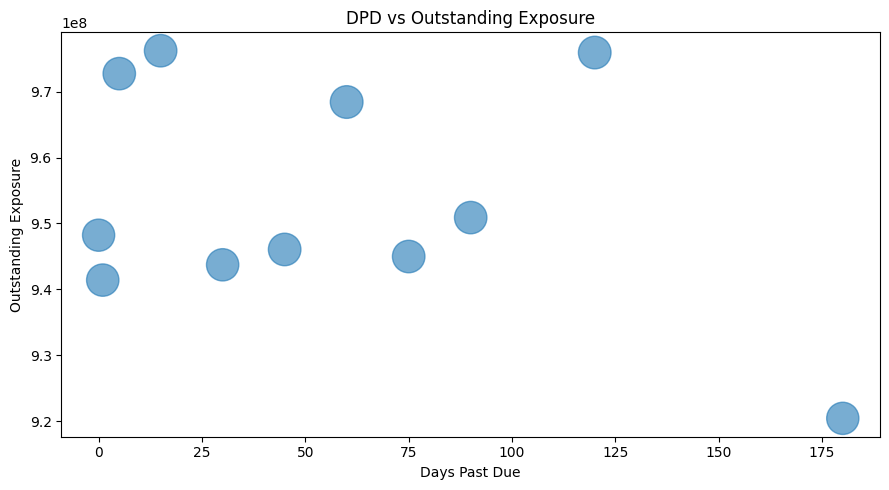

In [162]:
plt.figure(figsize=(9,5))

plt.scatter(
    dpd_summary["dpd"],
    dpd_summary["outstanding"],
    s=dpd_summary["accounts"] / 5,
    alpha=0.6
)

plt.title("DPD vs Outstanding Exposure")
plt.xlabel("Days Past Due")
plt.ylabel("Outstanding Exposure")

plt.tight_layout()
plt.show()

### Key EDA Observations

The exploratory analysis examines portfolio exposure, collection performance, collection activity, and delinquency levels. Risk-segment analysis helps identify where outstanding exposure is concentrated and where collection performance differs across segments.

The relationship between collection activity and payment outcomes is also examined to understand whether increased engagement is associated with stronger payment activity. DPD analysis provides additional context for prioritizing accounts based on delinquency and financial exposure.

These observations are used in the next stage to develop collection prioritization recommendations rather than relying on activity volume alone.

## 13. SQL Business Analysis

SQL is used to answer practical collection-management questions from the analytical data.

The queries focus on portfolio exposure, collection performance, account activity, promises-to-pay, and payment outcomes.

In [163]:
import sqlite3

# Create an in-memory SQL database
conn = sqlite3.connect(":memory:")

# Load important analytical tables into SQLite
analysis_df.to_sql("accounts_analysis", conn, index=False, if_exists="replace")
cleaned["accounts"].to_sql("accounts", conn, index=False, if_exists="replace")
cleaned["payments"].to_sql("payments", conn, index=False, if_exists="replace")
cleaned["calls"].to_sql("calls", conn, index=False, if_exists="replace")
cleaned["promises_to_pay"].to_sql("promises_to_pay", conn, index=False, if_exists="replace")

print("SQL environment created successfully.")

SQL environment created successfully.


### 13.1 Which risk segments have the highest outstanding exposure?

In [164]:
query = """
SELECT
    risk_segment,
    COUNT(DISTINCT account_id) AS accounts,
    ROUND(SUM(outstanding_amount), 2) AS outstanding_exposure
FROM accounts_analysis
GROUP BY risk_segment
ORDER BY outstanding_exposure DESC;
"""

display(pd.read_sql_query(query, conn))

,risk_segment,accounts,outstanding_exposure
0,HIGH,7552,2.646183e+09
1,LOW,7513,2.633311e+09
2,MEDIUM,7533,2.628179e+09
3,NPA,7402,2.581362e+09


### 13.2 Which risk segments have the strongest collection performance?

In [165]:
query = """
SELECT
    risk_segment,
    ROUND(SUM(outstanding_amount), 2) AS outstanding_exposure,
    ROUND(SUM(total_payment), 2) AS payments_collected,
    ROUND(
        SUM(total_payment) * 100.0 /
        NULLIF(SUM(outstanding_amount), 0), 2
    ) AS collection_rate
FROM accounts_analysis
GROUP BY risk_segment
ORDER BY collection_rate DESC;
"""

display(pd.read_sql_query(query, conn))

,risk_segment,outstanding_exposure,payments_collected,collection_rate
0,LOW,2.633311e+09,4.771991e+08,18.12
1,NPA,2.581362e+09,4.633775e+08,17.95
2,MEDIUM,2.628179e+09,4.680344e+08,17.81
3,HIGH,2.646183e+09,4.713486e+08,17.81


### 13.3 Which accounts have high outstanding exposure but no recorded payment?

In [166]:
query = """
SELECT
    account_id,
    risk_segment,
    dpd,
    outstanding_amount,
    call_count,
    ptp_count
FROM accounts_analysis
WHERE total_payment = 0
ORDER BY outstanding_amount DESC
LIMIT 20;
"""

display(pd.read_sql_query(query, conn))

,account_id,risk_segment,dpd,outstanding_amount,call_count,ptp_count
0,ACC0021684,HIGH,60,699829.11,2.0,1.0
1,ACC0018891,MEDIUM,60,699773.98,3.0,0.0
2,ACC0023058,LOW,45,699767.81,1.0,0.0
3,ACC0029494,HIGH,120,699592.58,3.0,1.0
4,ACC0021674,NPA,60,699558.22,6.0,0.0
5,ACC0008327,LOW,120,699452.69,5.0,2.0
6,ACC0022441,MEDIUM,5,699442.27,2.0,1.0
7,ACC0028271,HIGH,0,699389.56,6.0,0.0
8,ACC0016431,LOW,15,699347.19,5.0,0.0
9,ACC0027794,HIGH,180,699295.98,3.0,1.0


### 13.4 Which accounts made a promise-to-pay but have no recorded payment?

In [167]:
query = """
SELECT
    account_id,
    risk_segment,
    dpd,
    outstanding_amount,
    ptp_count,
    promised_amount,
    total_payment
FROM accounts_analysis
WHERE ptp_count > 0
  AND total_payment = 0
ORDER BY promised_amount DESC
LIMIT 20;
"""

display(pd.read_sql_query(query, conn))

,account_id,risk_segment,dpd,outstanding_amount,ptp_count,promised_amount,total_payment
0,ACC0004015,NPA,15,167410.59,6.0,361703.11,0.0
1,ACC0009085,LOW,15,301733.12,4.0,330948.07,0.0
2,ACC0009182,NPA,1,508003.31,4.0,328352.49,0.0
3,ACC0013947,LOW,0,675964.88,4.0,308559.68,0.0
4,ACC0019034,HIGH,90,462734.89,4.0,303513.10,0.0
5,ACC0018958,MEDIUM,90,387984.76,6.0,301925.17,0.0
6,ACC0001250,MEDIUM,120,515758.26,4.0,297499.91,0.0
7,ACC0008696,HIGH,90,359025.39,3.0,282620.75,0.0
8,ACC0019952,HIGH,1,667362.67,4.0,280797.55,0.0
9,ACC0013330,LOW,120,400704.02,4.0,278405.88,0.0


### 13.5 Which accounts received the highest collection activity?

In [168]:
query = """
SELECT
    account_id,
    risk_segment,
    outstanding_amount,
    call_count,
    total_payment
FROM accounts_analysis
ORDER BY call_count DESC
LIMIT 20;
"""

display(pd.read_sql_query(query, conn))

,account_id,risk_segment,outstanding_amount,call_count,total_payment
0,ACC0029834,NPA,573817.03,13.0,144076.03
1,ACC0008008,HIGH,2087.11,12.0,0.00
2,ACC0013276,NPA,461344.76,12.0,43948.31
3,ACC0001654,MEDIUM,241020.30,11.0,0.00
4,ACC0013315,HIGH,263159.65,11.0,109260.60
5,ACC0019883,HIGH,266255.09,11.0,0.00
6,ACC0020339,NPA,628861.83,11.0,0.00
7,ACC0020345,HIGH,334884.19,11.0,0.00
8,ACC0024365,NPA,391922.73,11.0,150681.82
9,ACC0025946,MEDIUM,640074.03,11.0,8908.26


## 14. Collection Prioritization Framework

Instead of prioritizing accounts solely by outstanding balance or collection activity, a simple explainable prioritization framework is developed.

The framework combines financial exposure, delinquency, payment status, and promise-to-pay behaviour to identify accounts that may require stronger follow-up.

The score is intended as an analytical prioritization tool rather than a predictive machine-learning model.

In [169]:
priority_df = analysis_df.copy()

priority_df["priority_score"] = 0

# Financial exposure
priority_df.loc[
    priority_df["outstanding_amount"] >=
    priority_df["outstanding_amount"].quantile(0.75),
    "priority_score"
] += 2

# High delinquency
priority_df.loc[
    priority_df["dpd"] >= priority_df["dpd"].quantile(0.75),
    "priority_score"
] += 2

# No payment recorded
priority_df.loc[
    priority_df["total_payment"] == 0,
    "priority_score"
] += 2

# PTP but no payment
priority_df.loc[
    (priority_df["ptp_count"] > 0) &
    (priority_df["total_payment"] == 0),
    "priority_score"
] += 3

priority_df["priority_band"] = pd.cut(
    priority_df["priority_score"],
    bins=[-1, 2, 5, 9],
    labels=["Low", "Medium", "High"]
)

priority_df[
    [
        "account_id",
        "risk_segment",
        "dpd",
        "outstanding_amount",
        "total_payment",
        "ptp_count",
        "promised_amount",
        "priority_score",
        "priority_band"
    ]
].sort_values(
    "priority_score",
    ascending=False
).head(20)

,account_id,risk_segment,dpd,outstanding_amount,total_payment,ptp_count,promised_amount,priority_score,priority_band
15994,ACC0015995,LOW,180,582921.10,0.0,1.0,90347.86,9,High
21509,ACC0021510,MEDIUM,120,605281.71,0.0,1.0,2851.38,9,High
8527,ACC0008528,NPA,120,594376.66,0.0,1.0,39508.71,9,High
27537,ACC0027538,MEDIUM,90,689927.43,0.0,1.0,41600.25,9,High
2113,ACC0002114,LOW,90,576526.70,0.0,1.0,95082.38,9,High
2105,ACC0002106,LOW,180,571483.42,0.0,2.0,110495.71,9,High
16053,ACC0016054,MEDIUM,180,639670.91,0.0,1.0,1320.76,9,High
29659,ACC0029660,NPA,90,684886.28,0.0,2.0,36654.21,9,High
15272,ACC0015273,HIGH,120,602181.83,0.0,1.0,97017.53,9,High
5469,ACC0005470,NPA,90,613577.21,0.0,2.0,8952.17,9,High


In [170]:
priority_summary = (
    priority_df
    .groupby("priority_band", observed=True)
    .agg(
        accounts=("account_id", "nunique"),
        outstanding=("outstanding_amount", "sum"),
        payments=("total_payment", "sum")
    )
    .reset_index()
)

priority_summary["collection_rate"] = (
    priority_summary["payments"] /
    priority_summary["outstanding"] * 100
)

display(priority_summary)

,priority_band,accounts,outstanding,payments,collection_rate
0,Low,19762,6.265714e+09,1.756129e+09,28.027588
1,Medium,7048,2.695881e+09,1.238310e+08,4.593341
2,High,3190,1.527440e+09,0.000000e+00,0.000000


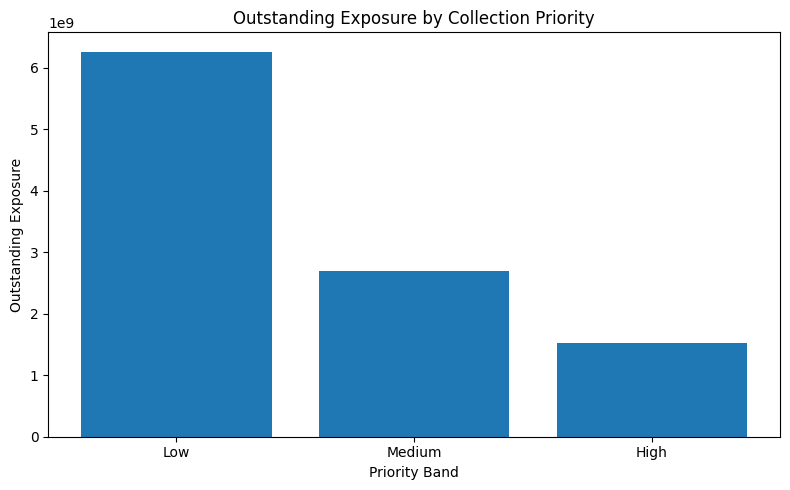

In [171]:
plt.figure(figsize=(8,5))

plt.bar(
    priority_summary["priority_band"].astype(str),
    priority_summary["outstanding"]
)

plt.title("Outstanding Exposure by Collection Priority")
plt.xlabel("Priority Band")
plt.ylabel("Outstanding Exposure")

plt.tight_layout()
plt.show()

## 15. Priority Account Identification

The prioritization framework is used to identify accounts combining high financial exposure, higher delinquency, limited payment activity, and unresolved promises-to-pay.

These accounts represent potential candidates for focused collection follow-up.

In [172]:
top_priority_accounts = (
    priority_df[
        priority_df["priority_band"] == "High"
    ]
    .sort_values(
        ["priority_score", "outstanding_amount"],
        ascending=[False, False]
    )
)

display(
    top_priority_accounts[
        [
            "account_id",
            "risk_segment",
            "dpd",
            "outstanding_amount",
            "total_payment",
            "ptp_count",
            "promised_amount",
            "call_count",
            "priority_score",
            "priority_band"
        ]
    ].head(20)
)

,account_id,risk_segment,dpd,outstanding_amount,total_payment,ptp_count,promised_amount,call_count,priority_score,priority_band
29493,ACC0029494,HIGH,120,699592.58,0.0,1.0,79930.32,3.0,9,High
8326,ACC0008327,LOW,120,699452.69,0.0,2.0,75957.12,5.0,9,High
27793,ACC0027794,HIGH,180,699295.98,0.0,1.0,88135.43,3.0,9,High
12471,ACC0012472,LOW,180,698770.70,0.0,1.0,53859.63,2.0,9,High
15104,ACC0015105,HIGH,180,698410.66,0.0,1.0,24398.97,2.0,9,High
26982,ACC0026983,MEDIUM,120,698156.98,0.0,1.0,9275.07,2.0,9,High
22861,ACC0022862,MEDIUM,90,698136.92,0.0,1.0,70245.52,4.0,9,High
23107,ACC0023108,HIGH,90,697812.29,0.0,2.0,111527.53,2.0,9,High
25082,ACC0025083,LOW,90,697113.36,0.0,3.0,176667.34,4.0,9,High
22540,ACC0022541,MEDIUM,180,697072.53,0.0,1.0,65643.33,2.0,9,High


## 16. Key Business Insights

### 1. Portfolio exposure is concentrated
The portfolio contains approximately ₹10.49 billion in outstanding exposure, while recorded payments total approximately ₹1.88 billion, resulting in an overall collection rate of approximately 17.92%.

### 2. Payment conversion requires attention
16,934 accounts have recorded payments, while 13,532 accounts have recorded promises-to-pay. Comparing these populations helps identify potential follow-up opportunities where commitments have not yet translated into payments.

### 3. Collection activity should not be evaluated only by volume
The number of calls alone does not establish collection effectiveness. Collection activity should be evaluated alongside payment outcomes and outstanding exposure.

### 4. Delinquency provides an important prioritization signal
DPD combined with outstanding exposure can help distinguish accounts that may require more urgent intervention from accounts with lower financial exposure.

### 5. Data quality can influence collection reporting
The dataset contains duplicate records, missing values, inconsistent identifiers, and relationship-level issues. Therefore, cleaning and validation are necessary before calculating operational KPIs.

### 6. A focused priority pool can improve collection efficiency
The proposed priority score combines financial exposure, delinquency, payment behaviour, and unresolved promises-to-pay. This provides an interpretable method for directing collection attention toward accounts with stronger business signals rather than simply contacting the highest number of accounts.

## 17. Business Recommendations

### Recommendation 1 — Prioritize high-exposure delinquent accounts
Focus collection resources on accounts where high outstanding balances coincide with elevated DPD.

### Recommendation 2 — Create a PTP follow-up queue
Accounts with a recorded promise-to-pay but no recorded payment should receive targeted follow-up before additional broad collection activity.

### Recommendation 3 — Use channel performance to guide targeting
Collection channels should be evaluated using payment outcomes rather than activity volume alone. Successful channels can receive greater targeting for similar account segments.

### Recommendation 4 — Monitor collection KPIs at account and segment level
Track outstanding exposure, payments collected, collection rate, PTP volume, payment conversion, and delinquency regularly.

### Recommendation 5 — Maintain a data-quality monitoring layer
Duplicate identifiers, missing values, inconsistent timestamps, and unmatched relationships should be monitored because they can distort operational reporting.

### Recommendation 6 — Use explainable prioritization before complex modelling
A transparent rule-based priority score provides an understandable starting point for collection teams. Once sufficient historical outcomes are available, this framework could later be extended into a predictive model.

## 19. Conclusion

The analysis demonstrates how collection data can be transformed from raw operational records into actionable collection intelligence.

The workflow covered data-quality assessment, preprocessing, relational validation, SQL-based business analysis, exploratory analysis, KPI development, and explainable collection prioritization.

The key outcome is a practical approach for identifying where collection teams may focus their efforts based on financial exposure, delinquency, payment behaviour, and promise-to-pay signals.

This framework can serve as a foundation for more advanced predictive collection strategies in the future.